In [ ]:
import pickle
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_auc_score


import matplotlib
print(matplotlib.__version__)
print(matplotlib.pyplot)
with open("xgb_model.pkl", "rb") as f:
    model = pickle.load(f)

test_df = pd.read_csv("test.csv")
X_test  = test_df.drop(columns=["TenYearCHD", "stratify"])
y_test  = test_df["TenYearCHD"]
y_pred  = model.predict(X_test)

# Split by sex (male=1, female=0)
female_mask = test_df["male"] == 0
male_mask   = test_df["male"] == 1

for label, mask in [("Female", female_mask), ("Male", male_mask)]:
    X = X_test[mask]
    y_true = y_test[mask]
    y_p    = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]
    print(f"\n── {label} ──────────────────────────────")
    print(classification_report(y_true, y_p))
    print(f"AUROC: {roc_auc_score(y_true, y_prob):.3f}")

with open("models/baseline_models/cardio_xgb_baseline_model.pkl", "rb") as f:
    model = pickle.load(f)

3.10.8
<module 'matplotlib.pyplot' from 'c:\\Users\\kavis\\OneDrive\\Desktop\\Study Resources\\Year 3\\Diss\\Code\\Dissertation_ExplainableAI\\.venv\\Lib\\site-packages\\matplotlib\\pyplot.py'>

── Female ──────────────────────────────


NameError: name 'classification_report' is not defined

In [22]:
test_df = pd.read_csv("data/test_train_val_sets/cardio_baseline_test.csv")
X_test = test_df.drop(columns=["cardio", "stratify"])
y_test = test_df["cardio"]
y_pred = model.predict(X_test)
print(test_df.columns.tolist())

['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'age_years', 'stratify']


False-negative women: 1337


c:\Users\kavis\OneDrive\Desktop\Study Resources\Year 3\Diss\Code\Dissertation_ExplainableAI\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



Feature comparison (woman vs matched male):
            FN Woman Matched Male
age_years         54           54
ap_hi            120          120
cholesterol        1            1
weight          68.0         68.0


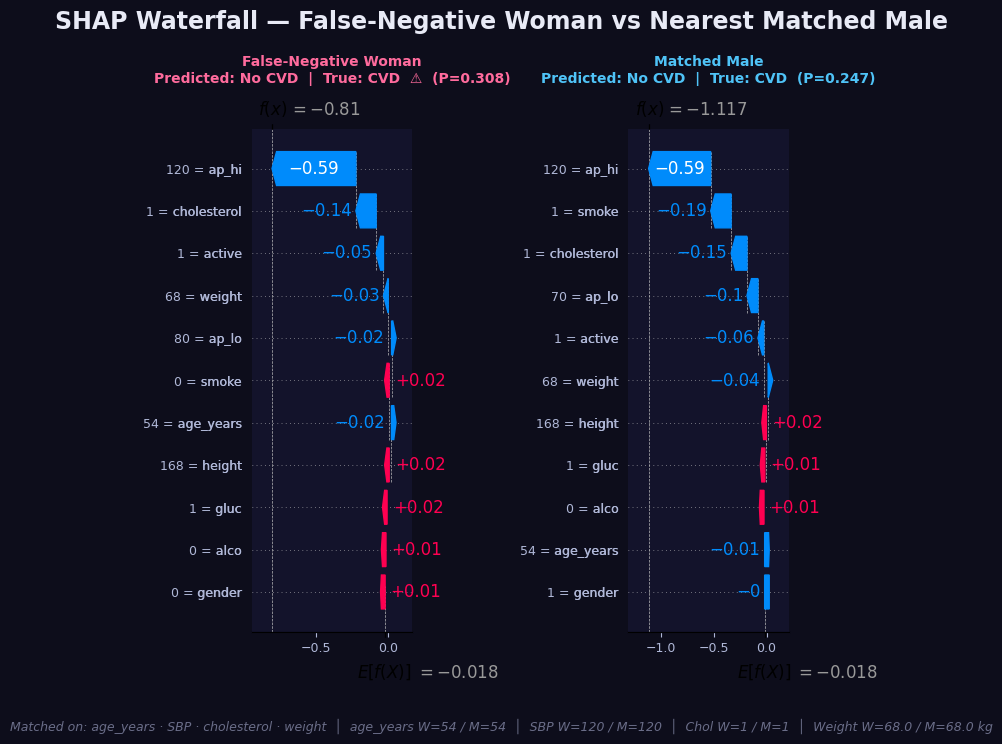


Top SHAP drivers (sorted by |woman SHAP|):
    feature  shap_woman  shap_male  diff (W-M)
      ap_hi     -0.5868    -0.5880     +0.0012
cholesterol     -0.1421    -0.1501     +0.0080
     active     -0.0511    -0.0551     +0.0040
     weight     -0.0333    -0.0419     +0.0086
      ap_lo     -0.0237    -0.1040     +0.0803
      smoke     +0.0171    -0.1934     +0.2105
  age_years     -0.0160    -0.0062     -0.0098
     height     +0.0157    +0.0170     -0.0013
       gluc     +0.0150    +0.0145     +0.0005
       alco     +0.0077    +0.0081     -0.0005


In [28]:
# ── Additional code: SHAP False-Negative Analysis ────────────────────────────
# Paste this after your existing model evaluation code
# import shap

import numpy as np
from sklearn.preprocessing import StandardScaler

MATCHING_FEATURES = ["age_years", "ap_hi", "cholesterol", "weight"]

# 1. Identify false-negative women (true=1, predicted=0, gender=0)
fn_mask    = (y_test.values == 1) & (y_pred == 0) & (test_df["gender"].values == 0)
fn_women   = test_df[fn_mask].copy()
fn_women_X = X_test[fn_mask].copy()
print(f"False-negative women: {len(fn_women)}")

# 2. Pick most representative FN woman (closest to median profile)
fn_std     = fn_women[MATCHING_FEATURES].std().replace(0, 1)
fn_median  = fn_women[MATCHING_FEATURES].median()
distances  = fn_women[MATCHING_FEATURES].apply(
    lambda row: np.linalg.norm((row - fn_median) / fn_std), axis=1
)
rep_idx     = distances.idxmin()
rep_woman   = fn_women.loc[rep_idx]
rep_woman_X = X_test.loc[rep_idx]

# 3. Find nearest male in test set (z-score normalised L2 distance)
males   = test_df[test_df["gender"] == 1].copy()
males_X = X_test[test_df["gender"].values == 1].copy()

scaler = StandardScaler()
scaler.fit(pd.concat([fn_women[MATCHING_FEATURES], males[MATCHING_FEATURES]]))

woman_scaled = scaler.transform(rep_woman[MATCHING_FEATURES].values.reshape(1, -1))
males_scaled = scaler.transform(males[MATCHING_FEATURES])

best_pos   = np.argmin(np.linalg.norm(males_scaled - woman_scaled, axis=1))
rep_male   = males.iloc[best_pos]
rep_male_X = males_X.iloc[best_pos]

print("\nFeature comparison (woman vs matched male):")
print(pd.DataFrame({
    "FN Woman":     rep_woman[MATCHING_FEATURES].values,
    "Matched Male": rep_male[MATCHING_FEATURES].values,
}, index=MATCHING_FEATURES))

# 4. SHAP explanations
explainer = shap.TreeExplainer(model)
woman_df  = pd.DataFrame(rep_woman_X.values.reshape(1, -1), columns=X_test.columns)
male_df   = pd.DataFrame(rep_male_X.values.reshape(1, -1),  columns=X_test.columns)
sv_woman  = explainer(woman_df)
sv_male   = explainer(male_df)

prob_woman = model.predict_proba(woman_df.values)[0, 1]
prob_male  = model.predict_proba(male_df.values)[0, 1]

# 5. Side-by-side waterfall plots
fig, axes = plt.subplots(1, 2, figsize=(26, 10))
fig.patch.set_facecolor("#0d0d1b")

panels = [
    dict(sv=sv_woman, ax=axes[0], title="False-Negative Woman",
         subtitle=f"Predicted: No CVD  |  True: CVD  ⚠️  (P={prob_woman:.3f})",
         accent="#ff6b9d"),
    dict(sv=sv_male,  ax=axes[1], title="Matched Male",
         subtitle=f"Predicted: {'CVD' if model.predict(male_df.values)[0]==1 else 'No CVD'}  "
                  f"|  True: {'CVD' if rep_male['cardio']==1 else 'No CVD'}  (P={prob_male:.3f})",
         accent="#4fc3f7"),
]

for p in panels:
    plt.sca(p["ax"])
    shap.plots.waterfall(p["sv"][0], max_display=12, show=False)
    p["ax"].set_facecolor("#13132b")
    for spine in p["ax"].spines.values():
        spine.set_edgecolor("#252540")
    p["ax"].tick_params(colors="#b0b8d8", labelsize=9)
    p["ax"].xaxis.label.set_color("#b0b8d8")
    p["ax"].set_title(f"{p['title']}\n{p['subtitle']}", color=p["accent"], fontsize=10, fontweight="bold", pad=12)    
fig.suptitle("SHAP Waterfall — False-Negative Woman vs Nearest Matched Male",
             fontsize=17, fontweight="bold", color="#e8eaf6", y=1.02)
fig.text(0.5, -0.01,
         f"Matched on: age_years · SBP · cholesterol · weight  │  "
         f"age_years W={int(rep_woman['age_years'])} / M={int(rep_male['age_years'])}  │  "
         f"SBP W={int(rep_woman['ap_hi'])} / M={int(rep_male['ap_hi'])}  │  "
         f"Chol W={int(rep_woman['cholesterol'])} / M={int(rep_male['cholesterol'])}  │  "
         f"Weight W={rep_woman['weight']:.1f} / M={rep_male['weight']:.1f} kg",
         ha="center", fontsize=9, color="#6a6d88", style="italic")

plt.tight_layout(pad=3.0)
plt.subplots_adjust(top=0.85)
plt.savefig("shap_fn_woman_vs_matched_male.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

# 6. Console SHAP driver summary
print("\nTop SHAP drivers (sorted by |woman SHAP|):")
print(pd.DataFrame({
    "feature":    X_test.columns,
    "shap_woman": sv_woman[0].values,
    "shap_male":  sv_male[0].values,
    "diff (W-M)": sv_woman[0].values - sv_male[0].values,
}).sort_values("shap_woman", key=abs, ascending=False).head(10).to_string(
    index=False, float_format="{:+.4f}".format))